# Normalizing Flows with [RealNVP](https://arxiv.org/pdf/1605.08803.pdf)

In this task you will implement a [RealNVP](https://arxiv.org/pdf/1605.08803.pdf) normalizing flows models, namely:

- a [RealNVP](https://arxiv.org/pdf/1605.08803.pdf) coupling layer,
- a full [RealNVP](https://arxiv.org/pdf/1605.08803.pdf) normalizing flow model,
- a normalizing flow loss.

First let us read the [RealNVP](https://arxiv.org/pdf/1605.08803.pdf) paper so we can proceed with implementation. Let us start with the dataset preparation. We will train our models on `DIGIT_NUMBER` digits from a `MNIST` dataset. Let us prepare our dataset:


In [ ]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader


DIGIT_NUMBER = 6
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dataset = torchvision.datasets.MNIST(root=r'./mnist/', 
                                     train=True,
                                     transform=transforms.ToTensor(),
                                     download=True)
x = (dataset.data.float() / 255. - 0.5)
y = dataset.targets
x = x[y == DIGIT_NUMBER].view(-1, 1, 28, 28).to(DEVICE)

dataloader = DataLoader(x, batch_size=128, shuffle=True)

Now - let us implement a `RealNVPCouplingLayer`. Each layer should have two functions:

- `forward_flow` - that performs operations similar to the ones described in the equation (7) of the original paper,
- `inverse_flow` - that performs operations similar to the ones described in the equation (8) of the original paper.

Each of these functions should output two tensors:
- `x` that is a result of a `RealNVPCouplingLayer` operations,
- `log_det` that is a value of a determinant of the Jacobian of the operation (for details look for the description of the equation (6) in the original paper).

Depending on the `parity` argument your model should:
- keep values of pixels with indices `(h, w)` for each pixel for which a sum of these indices: `h + w` is even and use these values to modify pixels for which a sum of indicies: `h + w` is odd according the paper if the `parity` argument is `True`,
- keep values of pixels with indices `(h, w)` for each pixel for which a sum of these indices: `h + w` is odd and use these values to modify pixels for which a sum of indicies: `h + w` is even according the paper if the `parity` argument is `False`,

The values `s` and `t` used to modify pixels should be a result of application of a two-layer, fully-connected neural network with `hidden_dims` number of neurons applied to a flattened set of pixels that are used for computations.

**Question:** What should be the output size of these neural networks? 

In [ ]:
from typing import Tuple


class RealNVPCouplingLayer(nn.Module):    

    def __init__(
        self,
        hidden_dims: int = 128,
        parity: bool = True,
    ):
        super().__init__()
        # TODO

    def forward_flow(self, x):
        #TODO
        return x, log_det

    
    def inverse_flow(self, x):
        #TODO
        return x, log_det

A small test that will confirm that your model works fine (the Maximal Difference should be relatively small (`< 0.001`).

In [ ]:
example_cl = RealNVPCouplingLayer().to(DEVICE)

print(
    f'Maximal Difference between the input tensor and reconstructed tensor is: '
    f'{torch.abs(example_cl.inverse_flow(example_cl.forward_flow(x)[0])[0] - x).sum()}.'
)

Maximal Difference between the input tensor and reconstructed tensor is: 0.05307336896657944.


Now - we are ready to the implementation of a `RealNVP` model. It will consist with the consecutive `RealNVPCouplingLayer`s with alternating parities. Your task is to implement two functions:

- `forward_flow` that will return a latent space embedding of a given image as well as log determinant of a Jacobian of a module,
- `inverse_flow` that will return an image from a given space embedding of a given example as well as log determinant of a Jacobian of a module.

**Hint** Log determinant of a Jacobian of a module is sum of log determinants of Jacobians of all coupling layers. 

These two functions should be roughly inverse to each other in terms of a latent representation and an image.

In [ ]:
class RealNVP(nn.Module):
    def __init__(
        self,
        hidden_dims: Tuple[int] = (128,) * 6,
    ):
        super().__init__()
        self.coupling_layers = nn.ModuleList(
            [
                RealNVPCouplingLayer(
                    hidden_dims=hidden_dim,
                    parity=cl_index // 2 == 0,
                )
                for cl_index, hidden_dim in enumerate(hidden_dims)
            ]
        )
        
    def forward_flow(self, x):
        #TODO
        return x, log_det
        
    def inverse_flow(self, x):
        #TODO
        return x, log_det

This test should confirm that `forward_flow` and `inverse_flow` are roughly inverse to each other (the difference should be relatively small (`< 0.01`):

In [ ]:
example_nf = RealNVP().to(DEVICE)

print(
    f'Maximal Difference between the input tensor and reconstructed tensor is: '
    f'{torch.abs(example_nf.inverse_flow(example_nf.forward_flow(x)[0])[0] - x).sum()}.'
)

Maximal Difference between the input tensor and reconstructed tensor is: 0.0014458610676229.


Now let us implement the loss function according to the equation (3) in the original paper. You should use a standard Gaussian prior $\mathcal{N}(0, I).$

**Hint:** Section 3.4 of [this](https://arxiv.org/pdf/1410.8516.pdf) paper might be useful.

In [ ]:
def nf_loss(z, logdetJ):
    #TODO

An really useful trick is to inject some noise into the input to improve the training. The following function should inject a random normal noise with `std` standard deviation:

In [ ]:
def dequantization(x, std=0.1):
    #TODO

Here are two functions that plot examples and paths in the latent space between two examples:

In [ ]:
import numpy as np


def plot(samples):
    length = len(samples)
    fig, ax = plt.subplots(1, length, figsize=(2*length, 2))
    fig.subplots_adjust(wspace=0, hspace=0, left=0, right=1, bottom=0, top=1)
    for j in range(length):
        ax[j].imshow(samples[j].cpu().numpy())
        ax[j].axis('off')
    plt.show()


def plot_random_samples(samples, model, steps):
    assert samples.shape[0] == 2
    encodings = model.forward_flow(samples)[0].cpu().detach().numpy()
    path_steps = []
    for i in np.linspace(0, 1, steps):
        current_step = encodings[0] + i * (encodings[1] - encodings[0])
        path_steps.append(current_step.reshape((1, *current_step.shape)))
    path = torch.tensor(np.concatenate(path_steps)).to(DEVICE)
    ambient_path = model.inverse_flow(path)[0]
    plot(ambient_path[:, 0])




Now let us train our model:

In [ ]:
L2_RATE = 0.001

model = RealNVP().to(DEVICE)


optimizer = torch.optim.Adam(model.parameters(), weight_decay=L2_RATE)

Epoch: 1/500 Loss: -883.7937
Random Samples from the latent space


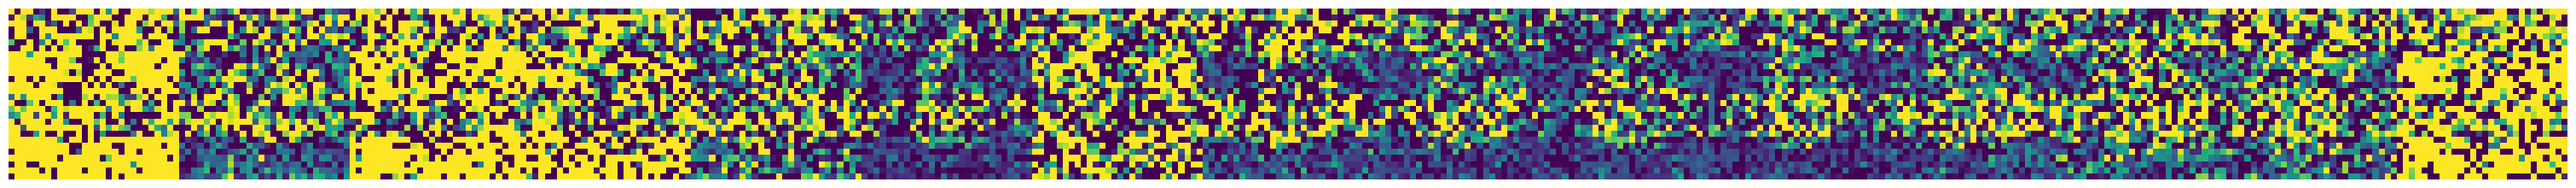

Random path between two examples


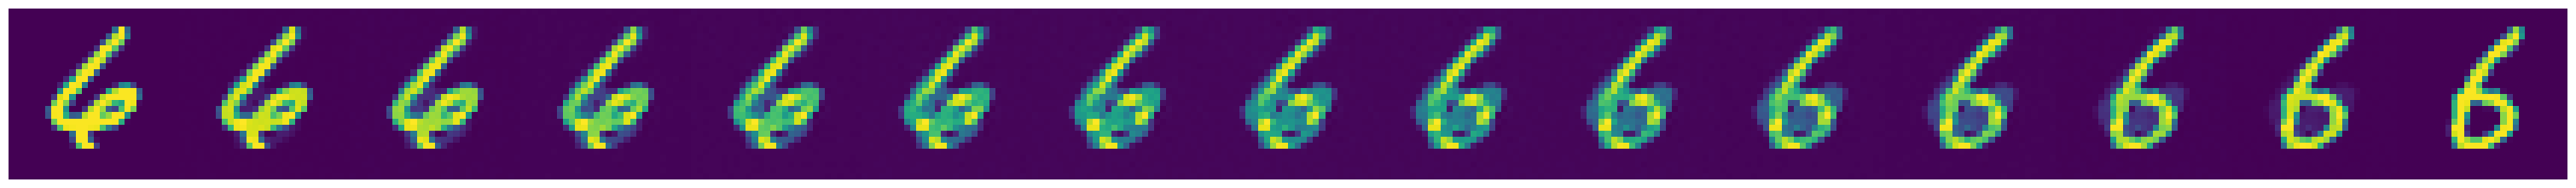

Epoch: 11/500 Loss: -1360.4531
Random Samples from the latent space


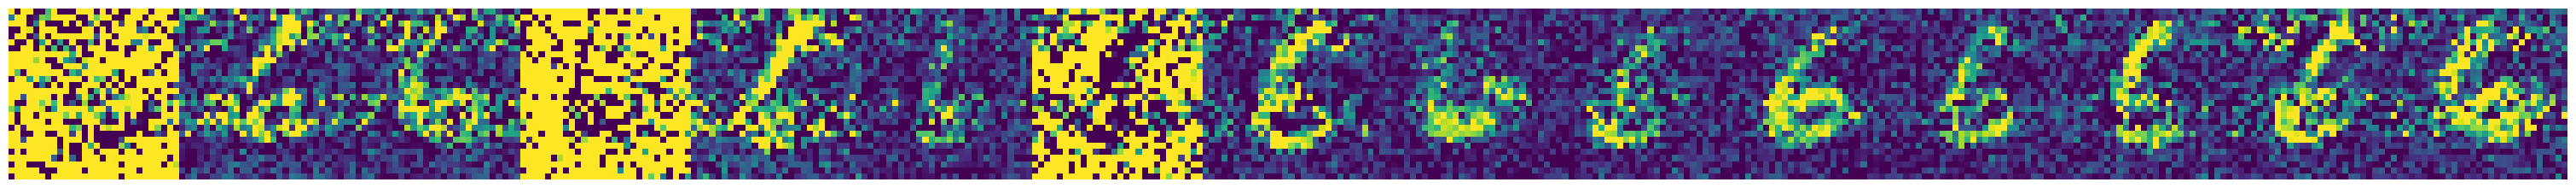

Random path between two examples


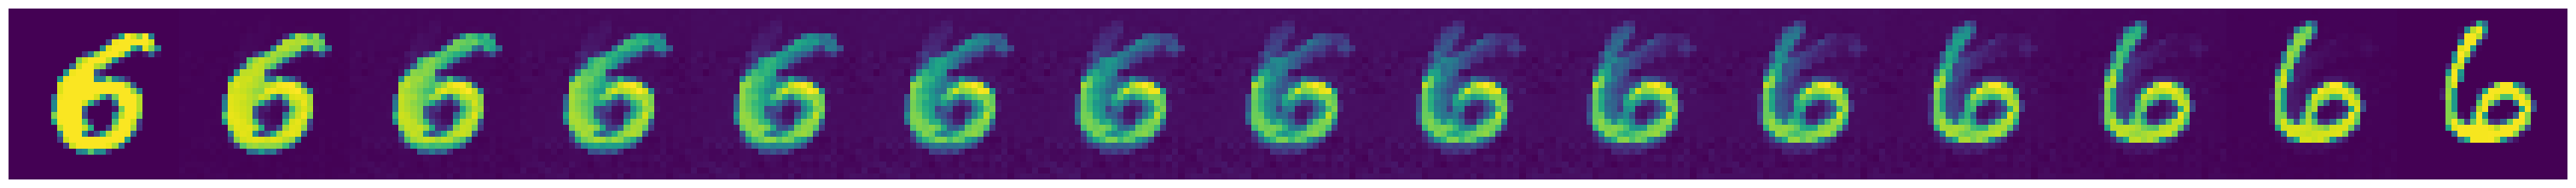

Epoch: 21/500 Loss: -1397.9025
Random Samples from the latent space


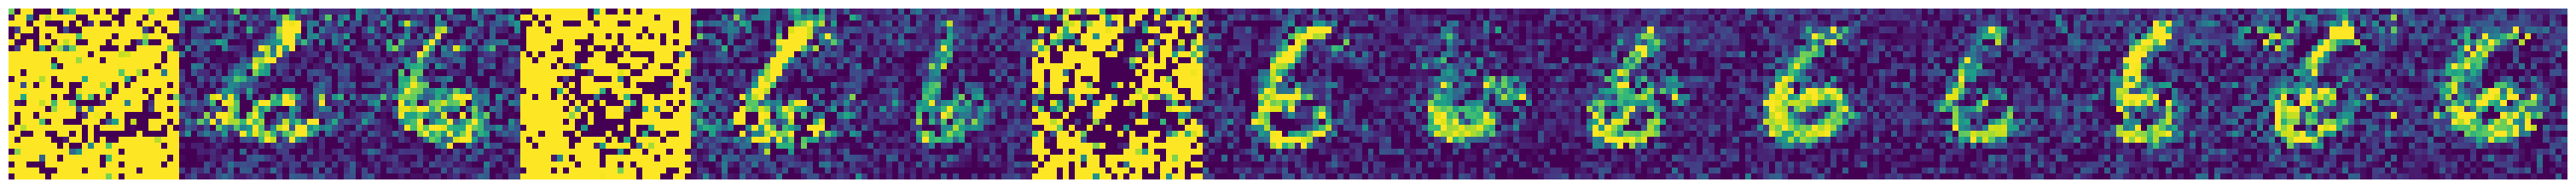

In [ ]:
NUMBER_OF_VISUALIZATION_SAMPLES = 15

sample_noise = torch.randn(NUMBER_OF_VISUALIZATION_SAMPLES, 1, 28,28).to(DEVICE)

n_epochs = 500
DEQUANTIZATION_STD = 0.1


for i in range(n_epochs):
    model.train()
    loss_acc = 0
    for j, x in enumerate(dataloader):
        optimizer.zero_grad()
        dq_x = dequantization(x, std=DEQUANTIZATION_STD)
        dq_x = torch.clip(dq_x, -0.5, 0.5)
        z, logdetJ = model.forward_flow(dq_x)
        loss = nf_loss(z, logdetJ)
        loss_acc += loss.item()
        loss.backward()
        optimizer.step()
    
    if i%10 == 0:
        print(f'Epoch: {i + 1}/{n_epochs} Loss: {(loss_acc / (j+1)):.4f}')
        with torch.no_grad():
            model.eval()
            samples, log_dj = model.inverse_flow(sample_noise)
            samples = torch.clip(samples, -0.5, 0.5)
            print('Random Samples from the latent space')
            plot(samples[:, 0])
            print('Random path between two examples')
            plot_random_samples(x[:2], model, NUMBER_OF_VISUALIZATION_SAMPLES)

Consider training successful if after a few hundred of epochs:
- most of the Random Samples from the latent space resemble true, but noisy digits (some of them might look like pure noise. This is an example of the so-called *hole problem* in generative modeling),
- most of the paths look like naturally evolving digits.

**Optional homework**: 
Unfortunately - the time constraints of classes made us to implement relatively simple models. You can either try to train your model for a longer period of time or try to improve this model by introducing more than one hidden layer to your coupling layer. 